In [3]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, random_split
from tqdm import tqdm
from PIL import Image
import math
import matplotlib.pyplot as plt

In [4]:
#====================================================================
#CONFIGURATION
#====================================================================
patch_dir = '/data/users4/pafshin1/My_Projects/RANDS/DATA/BLOCKS/INPUT_BLOCKS'
all_label_patch_dir = '/data/users4/pafshin1/My_Projects/RANDS/DATA/BLOCKS/INPUT_BLOCKS/metadata_blocks.csv'
bm_label_csv_dir = '/data/users4/pafshin1/My_Projects/RANDS/DATA/BLOCKS/INPUT_BLOCKS/metadata_output.csv'

#Which optimizer should be used: 'AdamW', 'NAdamW', 'Adam', 'NAdam', 'RMSprop', or 'SGD' (default: 'NAdamW')
recon_optimizer = 'NAdamW'

#What should the initial learning rate for the model optimizer(s) be (default: 1e-4)
recon_learningRate = 1e-4

#==================================================================
#Labels
#==================================================================
#Define general labels and values to use
labelBenign, labelMalignant, labelExclude = '0', '1', '2'
valueBenign, valueMalignant, valueBackground = int(labelBenign), int(labelMalignant), 2

#Define labels used for normal/benign tissue
#'a': normal adipose.
#'s': normal stroma tissue excluding adipose.
#'o': other normal tissue including parenchyma, adenosis, lobules, blood vessels, etc.
labelsBenign = ['a', 's', 'o', 'normal']

#Define labels used for malignant tissue
#'d': IDC tumor
#'l': ILC tumor
#'ot': other tumor areas including DCIS, biopsy site, and slightly defocused tumor regions.
labelsMalignant = ['d', 'l', 'ot', 'tumor']

#Define labels used for tissues to be excluded
#'ft': defocused but still visually tumor-like areas.
#'f': severly out-of-focusing areas. 
#'b': background. 
#'e': bubbles.
labelsExclude = ['ft', 'f', 'b', 'e', 'exclude']

# Load/synchronize data labeling, drop excluded rows, and extract relevant metadata
def loadMetadata_blocks(filename):
    metadata = pd.read_csv(filename, header=0, names=['Sample', 'Index', 'Row', 'Column', 'Label'], converters={'Sample': str, 'Index': str, 'Row': int, 'Column': int, 'Label': str})
    metadata['Label'] = metadata['Label'].replace(labelsBenign, labelBenign)
    metadata['Label'] = metadata['Label'].replace(labelsMalignant, labelMalignant)
    metadata['Label'] = metadata['Label'].replace(labelsExclude, labelExclude)
    metadata = metadata.loc[metadata['Label'] != labelExclude]
    return [np.squeeze(data) for data in np.split(np.asarray(metadata), [1, 2, 4], -1)]

# class TumorImageDataset(Dataset):
#     def __init__(self, csv_file, root_dir, transform=None):
#         """
#         Args:
#             csv_file (string): Path to the CSV file with image paths and labels.
#             root_dir (string): Directory with all the subfolders containing image patches.
#             transform (callable, optional): Optional transform to be applied on a sample.
#         """
#         self.metadata = pd.read_csv(csv_file)
#         self.root_dir = root_dir
#         self.transform = transform

#     def __len__(self):
#         return len(self.metadata)

#     def __getitem__(self, idx):
#         # Get the sample info from the metadata
#         sample_row = self.metadata.iloc[idx]
#         sample_name = sample_row['Sample']  # Example: '2_1'
#         index = sample_row['Index']          # Example: '1'
#         coordinates = sample_row['Coordinates'].strip("()")  # Example: "(5600, 2000)" to "5600, 2000"
        
#         # Remove any spaces before and after the row and column
#         row, column = [coord.strip() for coord in coordinates.split(",")]  # Strip spaces
#         formatted_coordinates = f"{row}_{column}"  # Format as row_column
#         label = int(sample_row['Label'])     # Example: '0' or '1'

#         # Construct the image path
#         image_name = f"PS{sample_name}_{index}_{formatted_coordinates}.tif"
#         image_path = os.path.join(self.root_dir, sample_name, image_name)

#         # Load the image
#         image = Image.open(image_path).convert('RGB')

#         # Apply transformations if any
#         if self.transform:
#             image = self.transform(image)

#         return image, torch.tensor(label, dtype=torch.long)



transform = transforms.Compose([
    transforms.ToTensor(),
])

In [7]:
import pandas as pd
import numpy as np

# Load/synchronize data labeling, drop excluded rows, and extract relevant metadata
def loadMetadata_blocks(filename):
    metadata = pd.read_csv(filename, header=0, names=['Sample', 'Index', 'Row', 'Column', 'Label'], converters={'Sample': str, 'Index': str, 'Row': int, 'Column': int, 'Label': str})
    metadata['Label'] = metadata['Label'].replace(labelsBenign, labelBenign)
    metadata['Label'] = metadata['Label'].replace(labelsMalignant, labelMalignant)
    metadata['Label'] = metadata['Label'].replace(labelsExclude, labelExclude)
    metadata = metadata.loc[metadata['Label'] != labelExclude]
    return [np.squeeze(data) for data in np.split(np.asarray(metadata), [1, 2, 4], -1)]

# File paths
label_patch_dir = '/data/users4/pafshin1/My_Projects copy/Rands/DATA/PATCHES/INPUT_PATCHES/metadata_patches.csv'

# Load metadata
metadata_output = loadMetadata_blocks(label_patch_dir)

# Create DataFrame from the metadata
df = pd.DataFrame({
    'Sample': metadata_output[0],
    'Index': metadata_output[1],
    'Coordinates': [f'({row[0]}, {row[1]})' for row in metadata_output[2]],
    'Label': metadata_output[3]
})

# Save DataFrame to CSV
output_csv_path = '/data/users4/pafshin1/My_Projects copy/Rands/DATA/PATCHES/INPUT_PATCHES/metadata_output_binary_label.csv'
df.to_csv(output_csv_path, index=False)

print(f'Metadata saved to {output_csv_path}')


Metadata saved to /data/users4/pafshin1/My_Projects copy/Rands/DATA/PATCHES/INPUT_PATCHES/metadata_output_binary_label.csv


In [4]:
class TumorImageDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        """
        Args:
            csv_file (string): Path to the CSV file with image paths and labels.
            root_dir (string): Directory with all the subfolders containing image patches.
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        self.metadata = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):
        # Get the sample info from the metadata
        sample_row = self.metadata.iloc[idx]
        sample_name = sample_row['Sample']  # Example: '2_1'
        index = sample_row['Index']          # Example: '1'
        coordinates = sample_row['Coordinates'].strip("()")  # Example: "(5600, 2000)" to "5600, 2000"
        
        # Remove any spaces before and after the row and column
        row, column = [coord.strip() for coord in coordinates.split(",")]  # Strip spaces
        formatted_coordinates = f"{row}_{column}"  # Format as row_column
        label = int(sample_row['Label'])     # Example: '0' or '1'

        # Construct the image path
        image_name = f"PS{sample_name}_{index}_{formatted_coordinates}.tif"
        image_path = os.path.join(self.root_dir, sample_name, image_name)

        # Load the image
        image = Image.open(image_path).convert('RGB')

        # Apply transformations if any
        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long), image_name


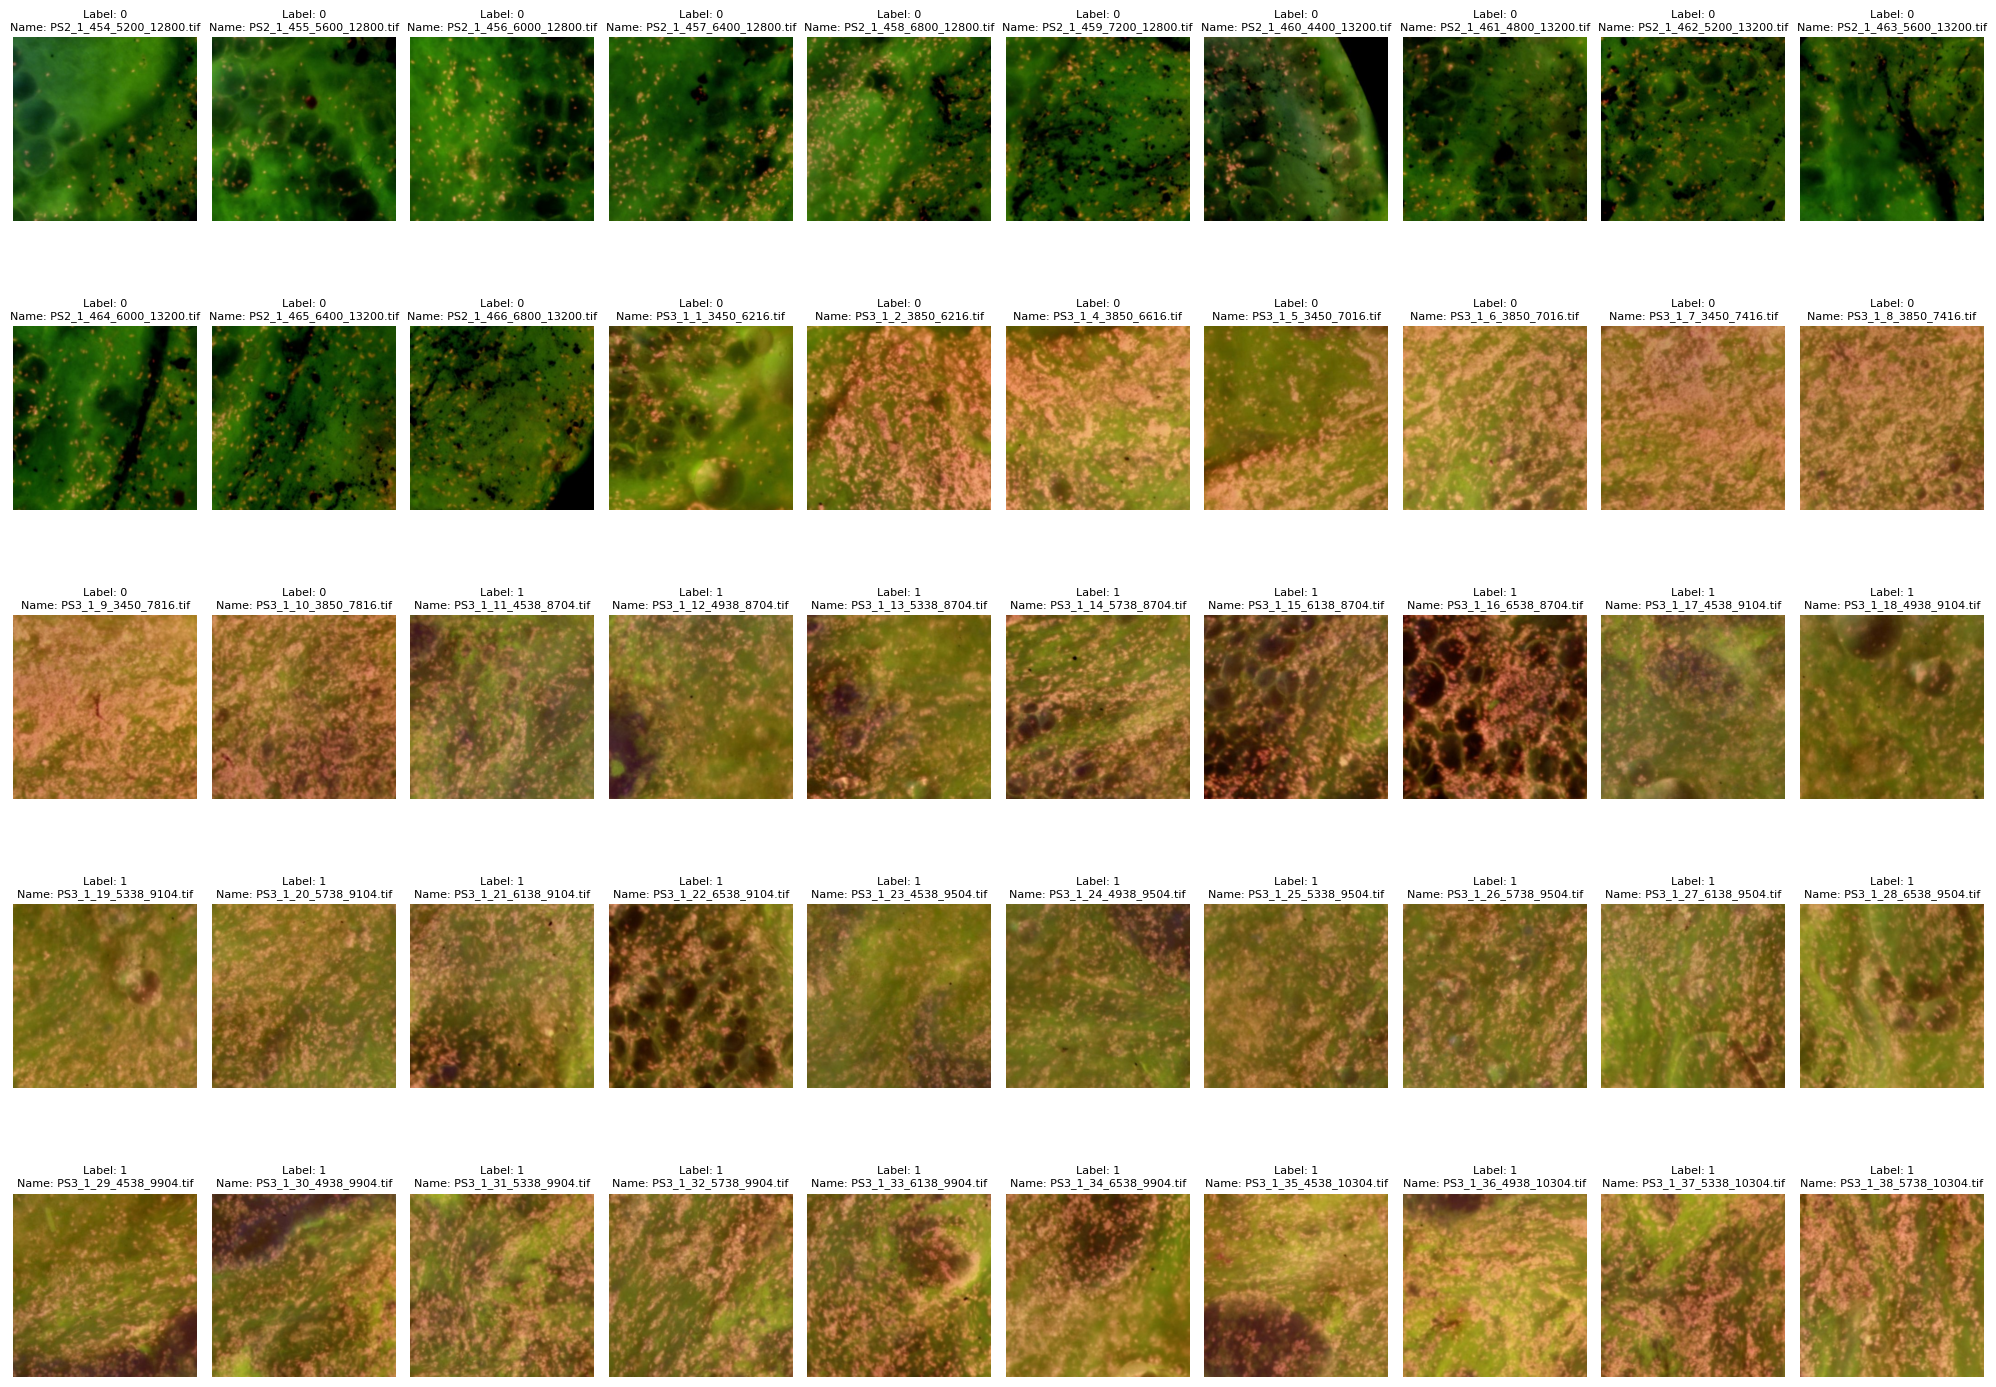

In [18]:
import matplotlib.pyplot as plt

# Define the dataset and the range for visualization
dataset = TumorImageDataset(csv_file=bm_label_csv_dir, root_dir=patch_dir, transform=transform)

def plot_images(start_idx, end_idx, dataset):
    num_images = end_idx - start_idx
    num_cols = 10  # Define the number of columns
    num_rows = num_images // num_cols  # Automatically calculate the number of rows

    fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(20, 15))
    axes = axes.flatten()

    for i, idx in enumerate(range(start_idx, end_idx)):
        image, label, image_name = dataset[idx]

        # Move channel to last dimension for plotting
        image = image.permute(1, 2, 0)

        # Plot the image with the label and name
        axes[i].imshow(image)
        axes[i].set_title(f"Label: {label}\nName: {image_name}", fontsize=8)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# Visualize images from index 460 to 510 (50 images)
plot_images(450, 500, dataset)


In [23]:
# Count the number of benign (label 0) and malignant (label 1) samples in the dataset
benign_count = 0
malignant_count = 0

for _, label,_ in dataset:
    if label == 0:
        benign_count += 1
    elif label == 1:
        malignant_count += 1

# Print the counts
print(f"Number of benign samples (label 0): {benign_count}")
print(f"Number of malignant samples (label 1): {malignant_count}")


Number of benign samples (label 0): 25033
Number of malignant samples (label 1): 11095


In [13]:
dataset = TumorImageDataset(csv_file=bm_label_csv_dir, root_dir=patch_dir, transform=transform)
total_size = len(dataset)
train_size = int(0.7 * total_size)   # 70% for training
val_size = int(0.15 * total_size)    # 15% for validation
test_size = total_size - train_size - val_size  # Remaining for test (15%)
train_size, val_size, test_size , train_size+val_size+test_size

(25289, 5419, 5420, 36128)

In [24]:
import pandas as pd

# Load the metadata CSV file
metadata = pd.read_csv('/data/users4/pafshin1/My_Projects/RANDS/DATA/BLOCKS/INPUT_BLOCKS/metadata_output.csv')

# Count the occurrences of each label (0 for benign, 1 for malignant)
label_counts = metadata['Label'].value_counts()

# Print the counts
print(f"Number of benign samples (label 0): {label_counts.get(0, 0)}")
print(f"Number of malignant samples (label 1): {label_counts.get(1, 0)}")


Number of benign samples (label 0): 25033
Number of malignant samples (label 1): 11095
